In [78]:
import geopandas as gpd
import pandas as pd
import json

# # 1. Load your BWA data
# with open('merged_json_output/merged_output.json', 'r') as f:
#     bwa_data = pd.DataFrame(json.load(f))


# 1. Load your BWA data
bwa_data = pd.read_excel("self_join_output.xlsx")






In [79]:
bwa_data.head(2)
print(bwa_data.columns)
# print(bwa_data['city'].value_counts())

Index(['url_issued', 'city', 'county', 'year_issued', 'issued_date_issued',
       'url_rescinded', 'rescinded_date_rescinded', 'duration_days'],
      dtype='object')


In [19]:
# 

In [101]:
# Geting Kansas county boundaries
# Download from: https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/
counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
ks_counties = counties[counties['STATEFP'] == '20'].copy()  # Kansas FIPS = 20
# counties.head()



In [ ]:
# Clean county names in bwd dataset and ks_counties for matching
bwa_data['county_clean'] = bwa_data['county'].str.replace(' County', '').str.strip().str.upper()
ks_counties['NAME'] = ks_counties['NAME'].str.upper()
# bwa_data.head()
# ks_counties

### Getting polygon geometry based on county only

In [ ]:
# Merge both the datasets on county name to get geometries
bwa_geo = bwa_data.merge(
    ks_counties[['NAME', 'GEOID', 'geometry']], 
    left_on='county_clean', 
    right_on='NAME', 
    how='left'
)

bwa_geo.head()

,url_issued,city,county,year_issued,issued_date_issued,url_rescinded,rescinded_date_rescinded,duration_days,county_clean,NAME,GEOID,geometry
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Rolling Hills Landowners Association,Seward County,2024,2024-02-21,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-04-18,57,SEWARD,SEWARD,20175,"POLYGON ((-101.07 37.388, -101.07 37.388, -101..."
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Quenemo,Osage County,2024,2024-02-28,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-15,16,OSAGE,OSAGE,20139,"POLYGON ((-95.6 38.434, -95.601 38.434, -95.60..."
2,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Quenemo,Osage County,2024,2024-03-05,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-15,10,OSAGE,OSAGE,20139,"POLYGON ((-95.6 38.434, -95.601 38.434, -95.60..."
3,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Fall River,Greenwood County,2024,2024-03-22,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-27,5,GREENWOOD,GREENWOOD,20073,"POLYGON ((-96.358 38.086, -96.358 38.088, -96...."
4,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Peabody,Marion County,2024,2024-03-26,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-28,2,MARION,MARION,20115,"POLYGON ((-97.151 38.61, -97.147 38.61, -97.14..."


### Geocoding based on city only

In [ ]:
from geopy.geocoders import Nominatim
from shapely.geometry import Point
import time

# Initializing geocoder
geolocator = Nominatim(user_agent="kansas_bwa_analysis")

def geocode_city(city, county):
    """Geocode Kansas city"""
    try:
        location = geolocator.geocode(f"{city}, {county}, Kansas, USA")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except:
        return None, None

# Apply geocoding (with delay to respect API limits)
bwa_data['lat'] = None
bwa_data['lon'] = None

for idx, row in bwa_data.iterrows():
    lat, lon = geocode_city(row['city'], row['county'])
    bwa_data.at[idx, 'lat'] = lat
    bwa_data.at[idx, 'lon'] = lon
    time.sleep(1)  # 1 second delay between requests
    
    if idx % 50 == 0:
        print(f"Geocoded {idx}/{len(bwa_data)}")

# Check results
print(f"\nSuccessfully geocoded: {bwa_data['lat'].notna().sum()}/{len(bwa_data)}")
print(f"\nFailed geocoding:")
print(bwa_data[bwa_data['lat'].isna()][['city', 'county']].drop_duplicates())

Geocoded 0/228
Geocoded 50/228
Geocoded 100/228
Geocoded 150/228
Geocoded 200/228

Successfully geocoded: 195/228

Failed geocoding:
                                      city               county
0     Rolling Hills Landowners Association        Seward County
8          Western Acres Mobile Home Court          Reno County
17   Walnut Grove Mobile Home Court Brooks  Pottawatomie County
19          Tuttle CC Mobile Home Park LLC         Riley County
22                      Nicodemus Township        Graham County
27                     YMCA Camp Hyde Inc.      Sedgwick County
35            Perry Place Mobile Home Park     Jefferson County
36             Riverchase Mobile Home Park         Riley County
41         Sundowner West Mobile Home Park        Saline County
45   Lakeside Village Improvement District     Jefferson County
50                          Sundowner Inc.        Saline County
111                    Seven Winds RV Park        Seward County
133     Prairie Schooner Mobile Hom

In [84]:
bwa_data

,url_issued,city,county,year_issued,issued_date_issued,url_rescinded,rescinded_date_rescinded,duration_days,county_clean,lat,lon
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Rolling Hills Landowners Association,Seward County,2024,2024-02-21,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-04-18,57,SEWARD,None,None
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Quenemo,Osage County,2024,2024-02-28,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-15,16,OSAGE,38.579733,-95.526926
2,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Quenemo,Osage County,2024,2024-03-05,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-15,10,OSAGE,38.579733,-95.526926
3,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Fall River,Greenwood County,2024,2024-03-22,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-27,5,GREENWOOD,37.607817,-96.028043
4,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Peabody,Marion County,2024,2024-03-26,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-28,2,MARION,38.16946,-97.106696
...,...,...,...,...,...,...,...,...,...,...,...
223,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Logan,Phillips County,2024,2024-01-17,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-01-19,2,PHILLIPS,39.661675,-99.570385
224,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Ransom,Ness County,2024,2024-01-18,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-01-24,6,NESS,38.636125,-99.933734
225,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Caney,Montgomery County,2024,2024-01-24,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-01-31,7,MONTGOMERY,37.011512,-95.935041
226,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,Quenemo,Osage County,2024,2024-02-06,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,2024-03-15,38,OSAGE,38.579733,-95.526926


In [ ]:
# bwa_data.to_excel('bwa_geocoded.xlsx', index=False, header=True)

### There are some locations that couldnot geocoded because of unincorporated locations and could not found lat lon for those.

In [85]:
# filtering bwa_data to include only rows with valid lat/lon
from sqlalchemy import Null


bwa_data_filtered = bwa_data[
    (bwa_data["lat"] != 0) & (bwa_data["lon"] != 0)
]

In [86]:
bwa_data_filtered['lat'].isnull().sum()

33

In [87]:
#select only rows with valid lat/lon and non-null lat/lon
bwa_data_valid = bwa_data[
    (bwa_data["lat"] != 0) & (bwa_data["lon"] != 0) & 
    (bwa_data["lat"].notnull()) & (bwa_data["lon"].notnull())
]

In [61]:
# bwa_data_valid['lat'].isnull().sum()

In [88]:
bwa_data_valid.shape    

(195, 11)

### Now creating point geometry for that specific location (or city)

In [94]:
from shapely.geometry import Point
import geopandas as gpd

# Create point geometries
geometry = [Point(xy) for xy in zip(bwa_data_valid['lon'], bwa_data_valid['lat'])]
bwa_gdf = gpd.GeoDataFrame(bwa_data_valid, geometry=geometry, crs='EPSG:4326')

In [95]:
# Convert to UTM Zone 14N (Kansas projection)
bwa_gdf = bwa_gdf.to_crs('EPSG:32614')

### Assuming that the extent of the advisory affect 10km area in the city

In [ ]:
# creating buffer = 10,000 meters (10km), for affected area around each point
bwa_gdf['buffer_geometry'] = bwa_gdf.geometry.buffer(10000)

In [97]:
bwa_gdf = bwa_gdf.set_geometry('buffer_geometry')
bwa_gdf = bwa_gdf.to_crs('EPSG:4326')

### Visulization on Kansas and US map

Buffers created!


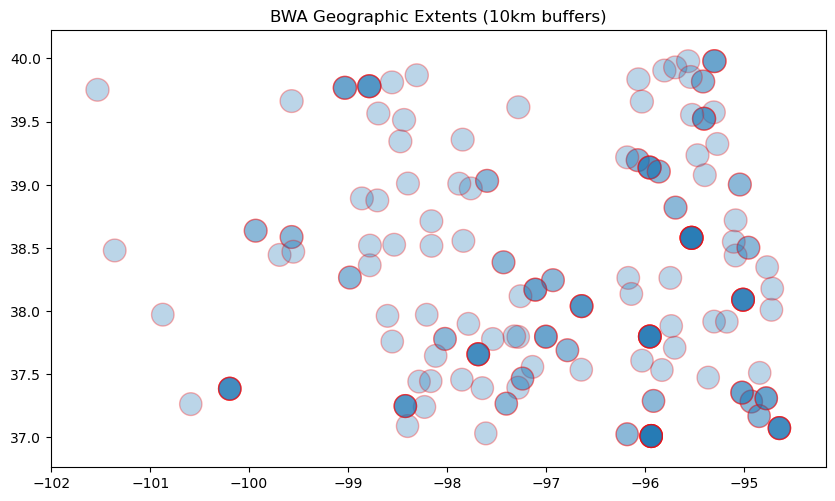

In [102]:
from matplotlib import pyplot as plt


print("Buffers created!")

# Quick visualization to check
ax = bwa_gdf.plot(figsize=(10, 8), alpha=0.3, edgecolor='red')
ax.set_title("BWA Geographic Extents (10km buffers)")
plt.show()

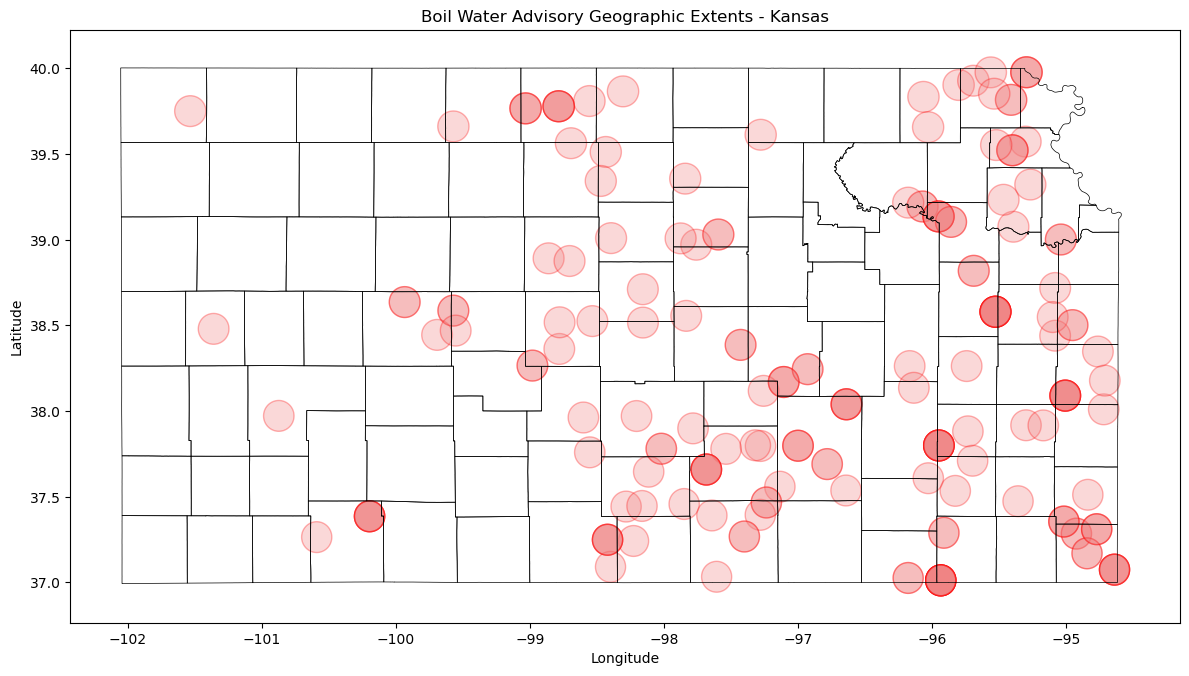

In [103]:
import matplotlib.pyplot as plt

# # Load Kansas counties (if you haven't already)
# counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
# ks_counties = counties[counties['STATEFP'] == '20'].to_crs('EPSG:4326')

# Plot with Kansas basemap
fig, ax = plt.subplots(figsize=(12, 8))

# Kansas counties as basemap
ks_counties.boundary.plot(ax=ax, linewidth=0.5, color='black')

# BWA buffers on top
bwa_gdf.plot(ax=ax, alpha=0.3, edgecolor='red', facecolor='lightcoral')

ax.set_title("Boil Water Advisory Geographic Extents - Kansas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

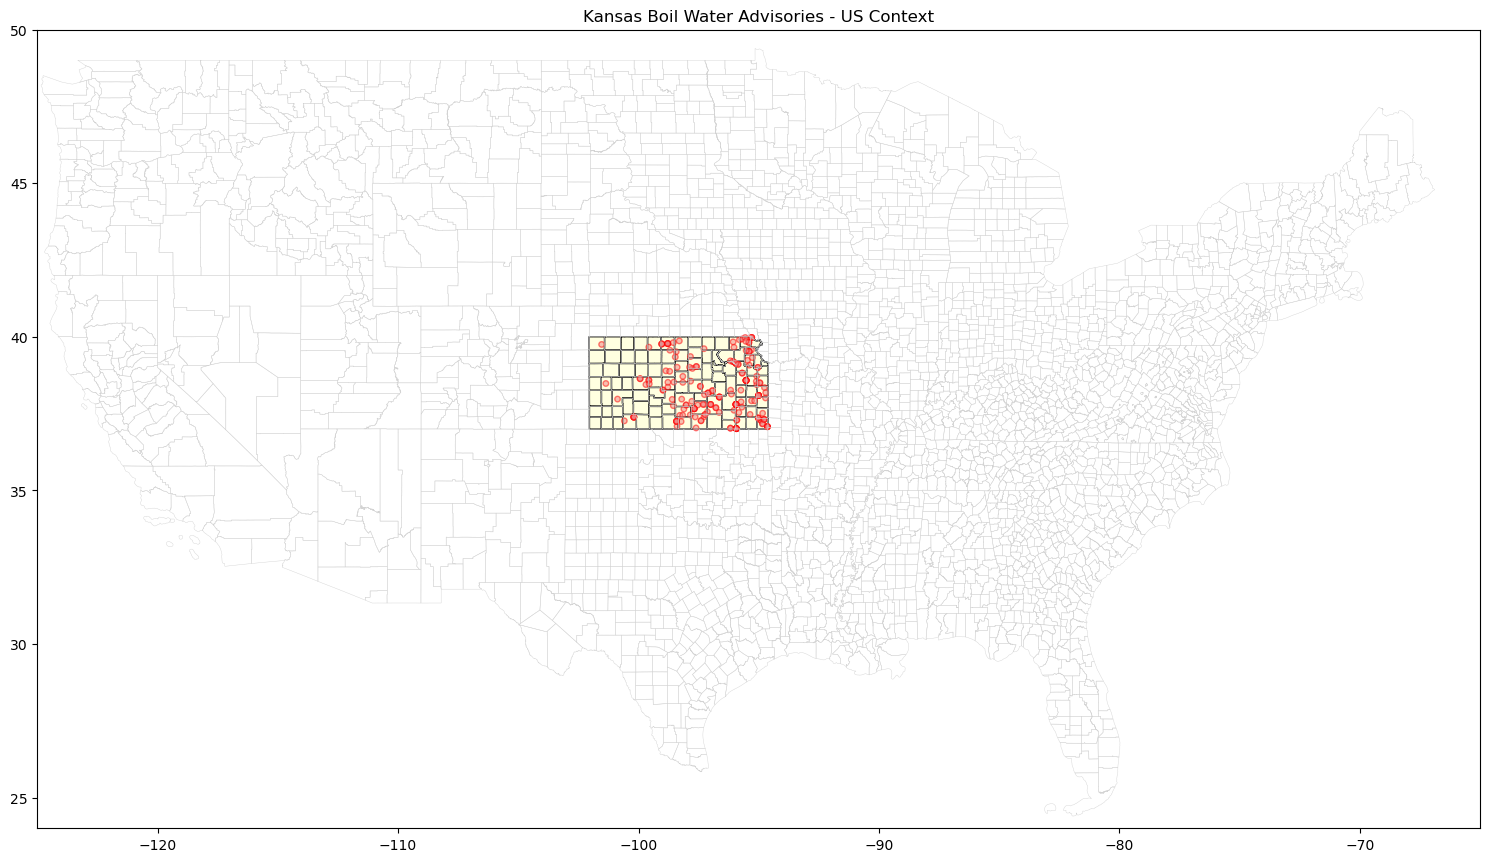

In [105]:

# Loading all US counties
us_counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
us_counties = us_counties.to_crs('EPSG:4326')

# Plot
fig, ax = plt.subplots(figsize=(15, 10))

# US counties as basemap (light gray)
us_counties.boundary.plot(ax=ax, linewidth=0.3, color='lightgray')

# Kansas counties highlighted
ks_counties = us_counties[us_counties['STATEFP'] == '20']
ks_counties.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=1)

# BWA buffers on top
bwa_gdf.plot(ax=ax, alpha=0.5, edgecolor='red', facecolor='lightcoral')

ax.set_title("Kansas Boil Water Advisories - US Context")
ax.set_xlim(-125, -65)  # Continental US
ax.set_ylim(24, 50)
plt.tight_layout()
plt.show()